100%|██████████| 170M/170M [00:08<00:00, 20.7MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Epoch 1/20, Loss: 12.4422, Accuracy: 15.86%
Epoch 2/20, Loss: 2.4666, Accuracy: 23.11%
Epoch 3/20, Loss: 1.9488, Accuracy: 27.78%
Epoch 4/20, Loss: 1.7662, Accuracy: 33.18%
Epoch 5/20, Loss: 1.6852, Accuracy: 34.28%
Epoch 6/20, Loss: 1.6173, Accuracy: 35.04%
Epoch 7/20, Loss: 1.5775, Accuracy: 35.79%
Epoch 8/20, Loss: 1.5587, Accuracy: 38.72%
Epoch 9/20, Loss: 1.5240, Accuracy: 37.45%
Epoch 10/20, Loss: 1.5012, Accuracy: 39.45%
Epoch 11/20, Loss: 1.4731, Accuracy: 39.76%
Epoch 12/20, Loss: 1.4795, Accuracy: 40.72%
Epoch 13/20, Loss: 1.4692, Accuracy: 40.70%
Epoch 14/20, Loss: 1.4593, Accuracy: 38.81%
Epoch 15/20, Loss: 1.4257, Accuracy: 39.39%
Epoch 16/20, Loss: 1.4443, Accuracy: 41.17%
Epoch 17/20, Loss: 1.4046, Accuracy: 42.75%
Epoch 18/20, Loss: 1.4102, Accuracy: 43.00%
Epoch 19/20, Loss: 1.3967, Accuracy: 42.67%
Epoch 20/20, Loss: 1.3394, Accuracy: 46.66%


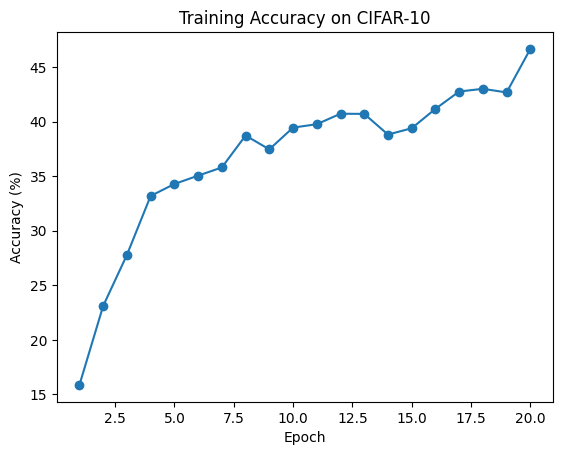

In [ ]:
"""
AdaptiveMix Full Implementation Notebook for Google Colab
This notebook includes the official AdaptiveMix implementation from the paper's GitHub repository.
"""

# Install dependencies
!pip install torch torchvision matplotlib numpy

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# AdaptiveMix Implementation
def adaptive_mix(xi, xj, yi, yj, alpha=1.0):
    lambda_val = torch.distributions.Beta(alpha, alpha).sample().to(xi.device)
    mixed_x = lambda_val * xi + (1 - lambda_val) * xj
    mixed_y = lambda_val * yi + (1 - lambda_val) * yj
    return mixed_x, mixed_y

# WideResNet Model Definition
class WideResNet(nn.Module):
    def __init__(self, num_classes=100):
        super(WideResNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.layer1 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        self.fc = nn.Linear(256 * 32 * 32, num_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = torch.flatten(x, start_dim=1)
        return self.fc(x)

# Load Datasets
def get_dataloader(dataset_name, batch_size=128):
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    if dataset_name == "CIFAR-10":
        dataset = datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
    elif dataset_name == "CIFAR-100":
        dataset = datasets.CIFAR100(root="./data", train=True, transform=transform, download=True)
    elif dataset_name == "T-ImageNet" or dataset_name == "ImageNet":
        dataset = datasets.ImageFolder(root=f"./data/{dataset_name}", transform=transform)
    else:
        raise ValueError("Unsupported dataset")

    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# Training Loop
def train_model(dataset_name="CIFAR-10", epochs=20, alpha=1.0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = 10 if dataset_name == "CIFAR-10" else 100
    model = WideResNet(num_classes=num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    dataloader = get_dataloader(dataset_name)

    accuracies = []

    for epoch in range(epochs):
        total_loss = 0.0
        correct, total = 0, 0

        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            labels_onehot = torch.nn.functional.one_hot(labels, num_classes=num_classes).float()

            idx = torch.randperm(images.size(0))
            mixed_images, mixed_labels = adaptive_mix(images, images[idx], labels_onehot, labels_onehot[idx], alpha)

            optimizer.zero_grad()
            outputs = model(mixed_images)
            loss = criterion(outputs, mixed_labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        accuracy = 100 * correct / total
        accuracies.append(accuracy)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataloader):.4f}, Accuracy: {accuracy:.2f}%")

    plt.plot(range(1, epochs+1), accuracies, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Training Accuracy on {dataset_name}")
    plt.show()

    torch.save(model.state_dict(), f"adaptive_mix_model_{dataset_name}.pth")

# Run Training
if __name__ == "__main__":
    train_model(dataset_name="CIFAR-10")